In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("/content/diamonds.csv")


In [3]:
df.head()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.tail()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [5]:
df.shape


(53940, 11)

In [6]:
df.columns


Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [8]:
df.describe()


,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
df.isnull().sum()


,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.mean(numeric_only=True)


,0
Unnamed: 0,26970.500000
carat,0.797940
depth,61.749405
table,57.457184
price,3932.799722
x,5.731157
y,5.734526
z,3.538734


In [12]:
df.median(numeric_only=True)


,0
Unnamed: 0,26970.50
carat,0.70
depth,61.80
table,57.00
price,2401.00
x,5.70
y,5.71
z,3.53


In [13]:
df.mode(numeric_only=True)


,Unnamed: 0,carat,depth,table,price,x,y,z
0,1,0.3,62.0,56.0,605.0,4.37,4.34,2.7
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
53935,53936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53936,53937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53937,53938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53938,53939,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.var(numeric_only=True)


,0
Unnamed: 0,2.424648e+08
carat,2.246867e-01
depth,2.052404e+00
table,4.992948e+00
price,1.591563e+07
x,1.258347e+00
y,1.304472e+00
z,4.980109e-01


In [15]:
df.std(numeric_only=True)


,0
Unnamed: 0,15571.281097
carat,0.474011
depth,1.432621
table,2.234491
price,3989.439738
x,1.121761
y,1.142135
z,0.705699


In [16]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

In [17]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Lower Limit: -5611.375
Upper Limit: 11885.625


In [18]:
outliers = df[(df['price'] < lower_limit) | (df['price'] > upper_limit)]

outliers


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
23820,23821,1.17,Ideal,F,VVS1,62.1,57.0,11886,6.82,6.73,4.21
23821,23822,2.08,Ideal,I,SI2,62.0,56.0,11886,8.21,8.10,5.06
23822,23823,1.70,Premium,I,VS2,62.2,58.0,11888,7.65,7.60,4.74
23823,23824,1.09,Ideal,F,IF,61.6,55.0,11888,6.59,6.65,4.08
23824,23825,1.68,Ideal,E,SI2,60.4,55.0,11888,7.79,7.70,4.68
...,...,...,...,...,...,...,...,...,...,...,...
27745,27746,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01
27746,27747,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11
27747,27748,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56
27748,27749,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04


In [19]:
len(outliers)


3540

In [20]:
df['price'] = np.where(df['price'] > upper_limit,
                       upper_limit,
                       df['price'])


In [21]:
outliers = df[(df['price'] < lower_limit) | (df['price'] > upper_limit)]

len(outliers)


0

In [22]:
correlation = df.corr(numeric_only=True)

correlation


,Unnamed: 0,carat,depth,table,price,x,y,z
Unnamed: 0,1.000000,-0.377983,-0.034800,-0.100830,-0.354470,-0.405440,-0.395843,-0.399208
carat,-0.377983,1.000000,0.028224,0.181618,0.929103,0.975094,0.951722,0.953387
depth,-0.034800,0.028224,1.000000,-0.295779,-0.007205,-0.025289,-0.029341,0.094924
table,-0.100830,0.181618,-0.295779,1.000000,0.133574,0.195344,0.183760,0.150929
price,-0.354470,0.929103,-0.007205,0.133574,1.000000,0.910590,0.891128,0.887767
x,-0.405440,0.975094,-0.025289,0.195344,0.910590,1.000000,0.974701,0.970772
y,-0.395843,0.951722,-0.029341,0.183760,0.891128,0.974701,1.000000,0.952006
z,-0.399208,0.953387,0.094924,0.150929,0.887767,0.970772,0.952006,1.000000


In [23]:
correlation['price'].sort_values(ascending=False)


,price
price,1.000000
carat,0.929103
x,0.910590
y,0.891128
z,0.887767
table,0.133574
depth,-0.007205
Unnamed: 0,-0.354470


In [24]:
df = df.drop('Unnamed: 0', axis=1)


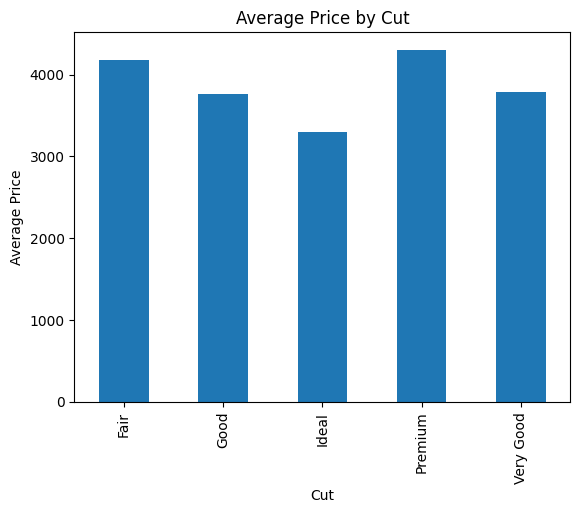

In [25]:
df.groupby('cut')['price'].mean().plot(kind='bar')

plt.title("Average Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Average Price")
plt.show()


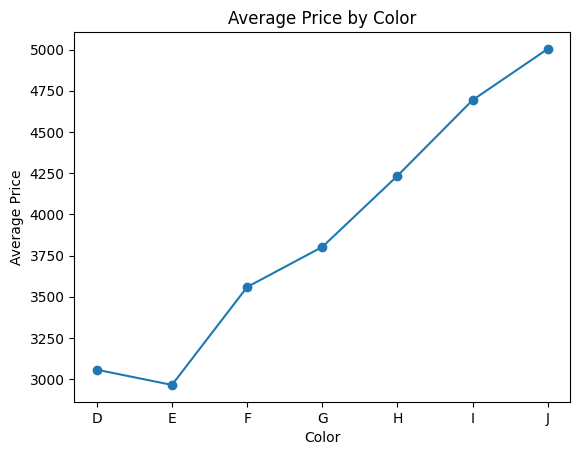

In [26]:
grouped = df.groupby('color')['price'].mean()

plt.plot(grouped.index, grouped.values, marker='o')

plt.xlabel('Color')
plt.ylabel('Average Price')
plt.title('Average Price by Color')
plt.show()

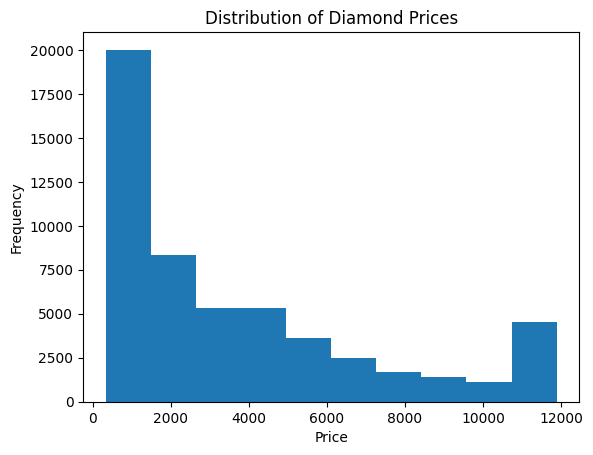

In [27]:
plt.hist(df['price'], bins=10)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Diamond Prices')
plt.show()

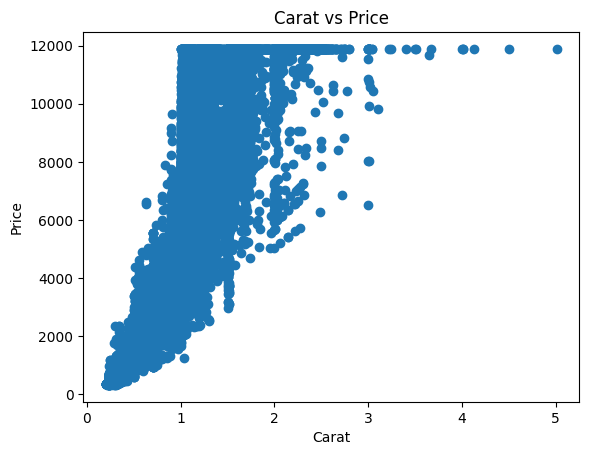

In [28]:
plt.scatter(df['carat'], df['price'])

plt.xlabel('Carat')
plt.ylabel('Price')
plt.title('Carat vs Price')
plt.show()
